# Hybrid ML–DL Crime Severity Classification Framework
### District-Level Crime Intelligence over a 10-Year Span (2014–2023)

**Research objective:** Build and benchmark a hybrid Machine Learning / Deep Learning framework that classifies Indian districts into multiclass **crime severity categories** (`Low`, `Moderate`, `High`, `Severe`) using engineered temporal and statistical features derived from district-level crime records, and explain model behaviour using SHAP.

**Dataset:** `india_district_crime_2014_2023_30k.csv` — 30,000 records covering 12 states, 300 districts, 10 crime types, 10 years (2014–2023).

**Pipeline overview**
1. Exploratory Data Analysis (EDA)
2. Feature Engineering (temporal + statistical + severity-weighted target construction)
3. Preprocessing (encoding, scaling, stratified split)
4. Baseline ML models: Logistic Regression, Random Forest, XGBoost, LightGBM, SVM
5. Deep Learning models: MLP, Bi-LSTM (sequence model over the 10-year district trajectory)
6. **Hybrid ML–DL architectures**
   - Hybrid A — Stacked Ensemble (XGBoost + LightGBM + Random Forest → Neural Meta-Learner)
   - Hybrid B — CNN–BiLSTM (temporal deep hybrid)
   - Hybrid C — Deep Autoencoder + XGBoost (DL feature extraction → ML classification)
   - Hybrid D — BiLSTM Embedding + XGBoost (temporal DL embedding → ML classification)
7. Unified evaluation: Accuracy, Precision, Recall, F1 (macro & weighted), ROC-AUC (multiclass OvR)
8. Explainability with SHAP
9. Results comparison & research discussion


## 1. Setup & Imports

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('TensorFlow:', tf.__version__)
print('XGBoost / LightGBM loaded OK')


I0000 00:00:1785605984.032011     544 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785606000.269587     544 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785606024.330777     544 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
XGBoost / LightGBM loaded OK


## 2. Load Data & Exploratory Data Analysis

The raw dataset is at **(District, Year, Crime_Type)** granularity — one row per crime category reported in a district in a given year.

In [2]:

df = pd.read_csv('india_district_crime_2014_2023_30k.csv')
print('Shape:', df.shape)
df.head()


Shape: (30000, 9)


,State,District,Year,Crime_Type,Cases_Reported,Chargesheeted,Convictions,Population,Crime_Rate_per_100k
0,Uttar Pradesh,Lucknow,2014,Murder,580,519,329,6843158,8.48
1,Uttar Pradesh,Lucknow,2014,Rape,682,553,213,6843158,9.97
2,Uttar Pradesh,Lucknow,2014,Kidnapping,206,163,92,6843158,3.01
3,Uttar Pradesh,Lucknow,2014,Theft,555,432,289,6843158,8.11
4,Uttar Pradesh,Lucknow,2014,Robbery,1068,718,309,6843158,15.61


In [3]:

print(df.info())
print('\nMissing values:\n', df.isnull().sum())
print('\nStates:', df.State.nunique(), '| Districts:', df.District.nunique(),
      '| Years:', df.Year.min(),'-', df.Year.max(), '| Crime types:', df.Crime_Type.nunique())
df.describe().T


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   State                30000 non-null  str    
 1   District             30000 non-null  str    
 2   Year                 30000 non-null  int64  
 3   Crime_Type           30000 non-null  str    
 4   Cases_Reported       30000 non-null  int64  
 5   Chargesheeted        30000 non-null  int64  
 6   Convictions          30000 non-null  int64  
 7   Population           30000 non-null  int64  
 8   Crime_Rate_per_100k  30000 non-null  float64
dtypes: float64(1), int64(5), str(3)
memory usage: 2.1 MB
None

Missing values:
 State                  0
District               0
Year                   0
Crime_Type             0
Cases_Reported         0
Chargesheeted          0
Convictions            0
Population             0
Crime_Rate_per_100k    0
dtype: int64

States: 12 | Districts: 300 | Yea

,count,mean,std,min,25%,50%,75%,max
Year,30000.0,2.018500e+03,2.872329e+00,2014.00,2016.00,2018.50,2.021000e+03,2023.00
Cases_Reported,30000.0,6.121470e+02,3.405679e+02,20.00,317.00,613.00,9.060000e+02,1200.00
Chargesheeted,30000.0,4.889778e+02,2.788880e+02,13.00,251.00,484.00,7.160000e+02,1135.00
Convictions,30000.0,2.687906e+02,1.670313e+02,5.00,130.00,254.00,3.840000e+02,835.00
Population,30000.0,3.923672e+06,1.750234e+06,810709.00,2304273.00,4038587.00,5.420266e+06,6937751.00
Crime_Rate_per_100k,30000.0,2.086315e+01,1.935145e+01,0.31,8.21,15.55,2.612250e+01,144.44


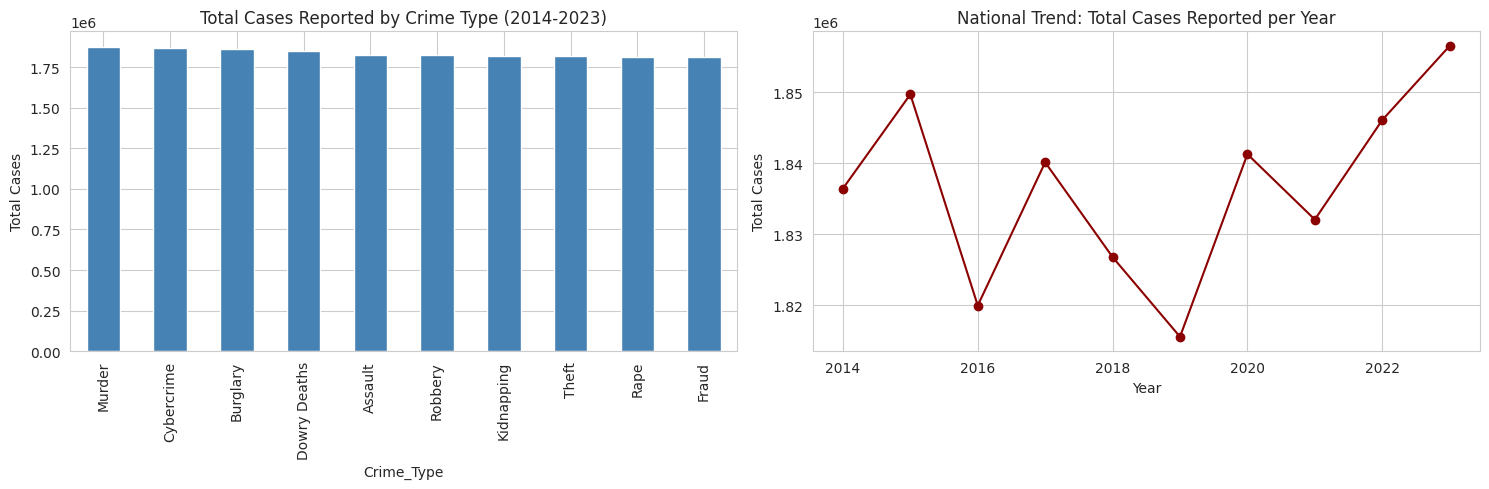

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df.groupby('Crime_Type')['Cases_Reported'].sum().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Cases Reported by Crime Type (2014-2023)')
axes[0].set_ylabel('Total Cases')

df.groupby('Year')['Cases_Reported'].sum().plot(kind='line', marker='o', ax=axes[1], color='darkred')
axes[1].set_title('National Trend: Total Cases Reported per Year')
axes[1].set_ylabel('Total Cases')
plt.tight_layout()
plt.show()


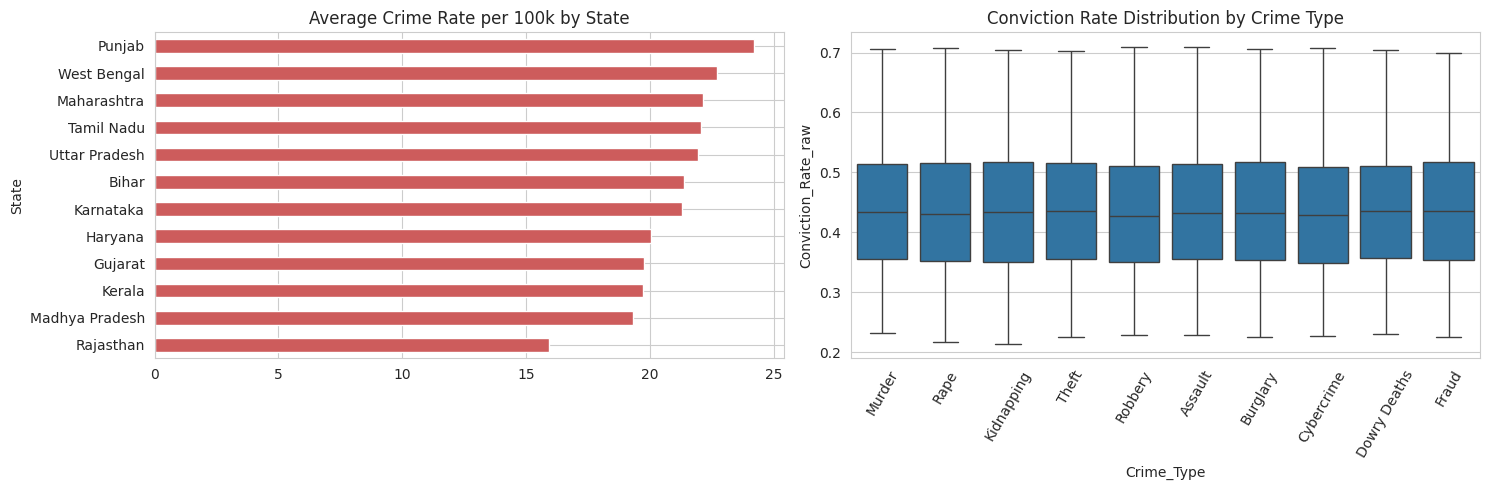

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
state_rate = df.groupby('State')['Crime_Rate_per_100k'].mean().sort_values(ascending=False)
state_rate.plot(kind='barh', ax=axes[0], color='indianred')
axes[0].set_title('Average Crime Rate per 100k by State')
axes[0].invert_yaxis()

df['Conviction_Rate_raw'] = df['Convictions'] / df['Cases_Reported']
sns.boxplot(data=df, x='Crime_Type', y='Conviction_Rate_raw', ax=axes[1])
axes[1].set_title('Conviction Rate Distribution by Crime Type')
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()


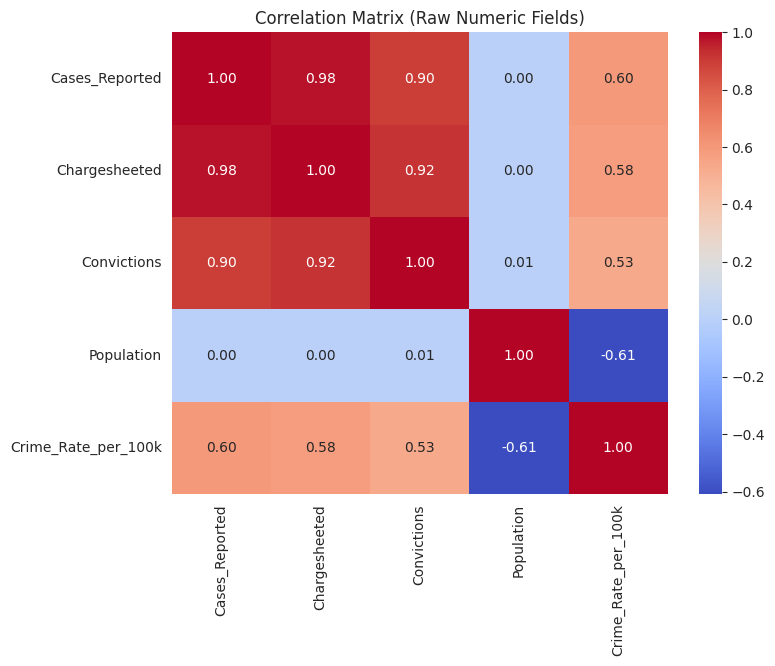

In [6]:

plt.figure(figsize=(8, 6))
corr = df[['Cases_Reported','Chargesheeted','Convictions','Population','Crime_Rate_per_100k']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Raw Numeric Fields)')
plt.show()


## 3. Feature Engineering

### 3.1 Choice of target variable

The raw dataset has **no explicit label**. For a research-grade multiclass classification framework we engineer a **Crime Severity Score** at the **(District, Year)** level, combining:

| Component | Rationale | Weight |
|---|---|---|
| Severity-weighted crime rate | Not all crimes are equally severe — violent/heinous crimes (Murder, Rape, Dowry Deaths, Kidnapping) are weighted higher than property/cyber crimes (Theft, Fraud, Cybercrime), following NCRB's IPC severity conventions | 0.45 |
| Average raw crime rate per 100k | Captures overall crime intensity regardless of type | 0.20 |
| YoY growth in weighted crime rate | Temporal feature — a district trending upward is more concerning than a stable high-crime district | 0.15 |
| Impunity factor (1 − conviction rate) | Statistical/legal-outcome feature — low conviction relative to cases reported signals systemic severity | 0.20 |

The continuous **Severity_Score** is then discretized via quantile binning into **4 balanced classes**: `Low`, `Moderate`, `High`, `Severe`. This is the target variable used across all models below.

### 3.2 Engineered features

- **Severity weighting** of each crime type (domain knowledge-informed)
- **Statistical features**: Conviction_Rate & Chargesheet_Rate (used only for target construction / EDA — Conviction_Rate excluded from model input, see leakage guard below), Crime_Diversity (Shannon entropy across the 10 crime types per district-year), and **crime-type composition shares** (the % of a district-year's cases belonging to each of the 10 crime types — genuinely independent of the severity formula)
- **Temporal features**, computed causally (only current & past years, no future leakage) **on `Total_Cases`** rather than on the target-defining rate: YoY growth, 3-year rolling mean/std, expanding linear trend slope
- **Cross-sectional (state-relative) features**: Z-score and percentile rank of a district's *peak* crime-type rate (`Max_Crime_Rate`) within its state and year


In [7]:

severity_weights = {
    'Murder': 10, 'Dowry Deaths': 9, 'Rape': 9, 'Kidnapping': 7,
    'Robbery': 6, 'Assault': 5, 'Burglary': 4, 'Theft': 3,
    'Fraud': 3, 'Cybercrime': 2
}
df['Severity_Weight'] = df['Crime_Type'].map(severity_weights)
df['Weighted_Cases'] = df['Cases_Reported'] * df['Severity_Weight']

# ---- Aggregate to District-Year level ----
agg = df.groupby(['State', 'District', 'Year']).agg(
    Population=('Population', 'first'),
    Total_Cases=('Cases_Reported', 'sum'),
    Total_Chargesheeted=('Chargesheeted', 'sum'),
    Total_Convictions=('Convictions', 'sum'),
    Weighted_Cases=('Weighted_Cases', 'sum'),
    Avg_Crime_Rate=('Crime_Rate_per_100k', 'mean'),
    Max_Crime_Rate=('Crime_Rate_per_100k', 'max'),
).reset_index()

agg['Conviction_Rate'] = agg['Total_Convictions'] / agg['Total_Cases']
agg['Chargesheet_Rate'] = agg['Total_Chargesheeted'] / agg['Total_Cases']
agg['Weighted_Crime_Rate'] = agg['Weighted_Cases'] / agg['Population'] * 100000

# ---- Crime-type diversity (Shannon entropy) ----
def entropy(g):
    p = g['Cases_Reported'] / g['Cases_Reported'].sum()
    p = p[p > 0]
    return -(p * np.log(p)).sum()

ent = df.groupby(['District', 'Year']).apply(entropy, include_groups=False)
ent = ent.rename('Crime_Diversity').reset_index()
agg = agg.merge(ent, on=['District', 'Year']).sort_values(['District', 'Year']).reset_index(drop=True)

print('District-Year aggregated shape:', agg.shape)
agg.head()


District-Year aggregated shape: (3000, 14)


,State,District,Year,Population,Total_Cases,Total_Chargesheeted,Total_Convictions,Weighted_Cases,Avg_Crime_Rate,Max_Crime_Rate,Conviction_Rate,Chargesheet_Rate,Weighted_Crime_Rate,Crime_Diversity
0,Punjab,Abohar,2014,2731488,5204,3963,1946,33435,19.051,39.54,0.373943,0.761530,1224.058096,2.104734
1,Punjab,Abohar,2015,2731488,7053,5674,2718,42271,25.822,39.65,0.385368,0.804480,1547.544781,2.275962
2,Punjab,Abohar,2016,2731488,4933,4260,2424,32078,18.061,42.36,0.491385,0.863572,1174.378214,2.084518
3,Punjab,Abohar,2017,2731488,6304,4856,2706,36349,23.080,43.90,0.429251,0.770305,1330.739875,2.117610
4,Punjab,Abohar,2018,2731488,6869,5427,3058,43742,25.146,43.27,0.445189,0.790071,1601.398212,2.217198


> **Target-leakage guard.** `Weighted_Crime_Rate`, `Avg_Crime_Rate`, `YoY_Growth` (of Weighted_Crime_Rate) and `Conviction_Rate` are the four ingredients of `Severity_Score` (below). If we also fed those exact columns into the models as predictors, the classification task would collapse into recovering a known linear formula -- a textbook target-leakage pitfall that would not survive peer review. To keep the framework genuinely predictive, everything used to build the target lives in a "target-only" block, and the model-facing feature set (`feature_cols`, Section 4) is built from a disjoint set of signals: raw case volumes, chargesheet outcomes, crime-type composition/mix, and temporal dynamics computed on `Total_Cases` rather than on the target-defining rate.

In [8]:

# ---- TARGET-ONLY temporal feature (used solely to build Severity_Score, never fed to models) ----
def target_temporal_feats(g):
    g = g.sort_values('Year').copy()
    g['YoY_Growth'] = g['Weighted_Crime_Rate'].pct_change().fillna(0)
    return g

agg = agg.groupby('District').apply(target_temporal_feats, include_groups=False)
agg = agg.reset_index(level=0).reset_index(drop=True)

# ---- MODEL-FACING temporal features, computed on Total_Cases (independent of target formula) ----
def model_temporal_feats(g):
    g = g.sort_values('Year').copy()
    g['Cases_YoY'] = g['Total_Cases'].pct_change().fillna(0)
    g['Cases_Roll3_Mean'] = g['Total_Cases'].rolling(3, min_periods=1).mean()
    g['Cases_Roll3_Std'] = g['Total_Cases'].rolling(3, min_periods=1).std().fillna(0)
    yrs = g['Year'].values
    vals = g['Total_Cases'].values
    slopes = [0.0 if i < 1 else np.polyfit(yrs[:i+1], vals[:i+1], 1)[0] for i in range(len(g))]
    g['Cases_Trend_Slope'] = slopes
    return g

agg = agg.groupby('District').apply(model_temporal_feats, include_groups=False)
agg = agg.reset_index(level=0).reset_index(drop=True)

# ---- State-relative (cross-sectional) features, computed on Max_Crime_Rate (NOT a target ingredient) ----
agg['State_Year_Z'] = agg.groupby(['State', 'Year'])['Max_Crime_Rate'] \
    .transform(lambda x: (x - x.mean()) / (x.std() + 1e-9))
agg['State_Year_Rank_Pct'] = agg.groupby(['State', 'Year'])['Max_Crime_Rate'].rank(pct=True)

# ---- Crime-type composition (mix) -- genuinely independent of the severity formula ----
type_pivot = df.pivot_table(index=['District', 'Year'], columns='Crime_Type',
                             values='Cases_Reported', aggfunc='sum', fill_value=0)
type_share = type_pivot.div(type_pivot.sum(axis=1), axis=0)
type_share.columns = [f'Share_{c.replace(" ", "_")}' for c in type_share.columns]
type_share = type_share.reset_index()
agg = agg.merge(type_share, on=['District', 'Year'])

print('Final engineered feature set shape:', agg.shape)
agg.columns.tolist()


Final engineered feature set shape: (3000, 31)


['District',
 'State',
 'Year',
 'Population',
 'Total_Cases',
 'Total_Chargesheeted',
 'Total_Convictions',
 'Weighted_Cases',
 'Avg_Crime_Rate',
 'Max_Crime_Rate',
 'Conviction_Rate',
 'Chargesheet_Rate',
 'Weighted_Crime_Rate',
 'Crime_Diversity',
 'YoY_Growth',
 'Cases_YoY',
 'Cases_Roll3_Mean',
 'Cases_Roll3_Std',
 'Cases_Trend_Slope',
 'State_Year_Z',
 'State_Year_Rank_Pct',
 'Share_Assault',
 'Share_Burglary',
 'Share_Cybercrime',
 'Share_Dowry_Deaths',
 'Share_Fraud',
 'Share_Kidnapping',
 'Share_Murder',
 'Share_Rape',
 'Share_Robbery',
 'Share_Theft']

Severity_Class
Low         750
Moderate    750
High        750
Severe      750
Name: count, dtype: int64


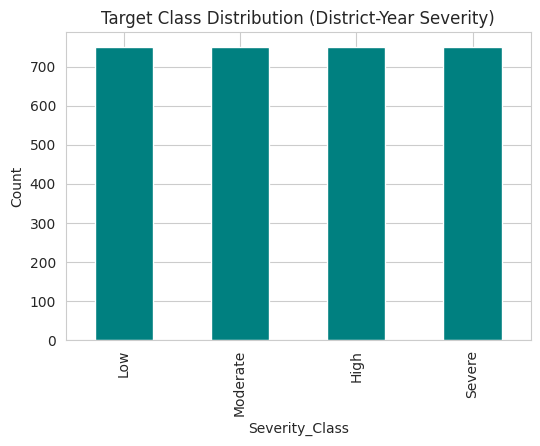

In [9]:

# ---- Target construction: Severity_Score -> Severity_Class (4-class) ----
minmax = MinMaxScaler()
norm = pd.DataFrame(
    minmax.fit_transform(agg[['Weighted_Crime_Rate', 'Avg_Crime_Rate', 'YoY_Growth']]),
    columns=['n_wcr', 'n_acr', 'n_yoy']
)
impunity = 1 - agg['Conviction_Rate'].fillna(0)
norm['n_imp'] = MinMaxScaler().fit_transform(impunity.values.reshape(-1, 1))

agg['Severity_Score'] = (
    0.45 * norm['n_wcr'] +
    0.20 * norm['n_acr'] +
    0.15 * norm['n_yoy'].clip(0, 1) +
    0.20 * norm['n_imp']
)

agg['Severity_Class'] = pd.qcut(agg['Severity_Score'], 4, labels=['Low', 'Moderate', 'High', 'Severe'])

print(agg['Severity_Class'].value_counts())
plt.figure(figsize=(6,4))
agg['Severity_Class'].value_counts().reindex(['Low','Moderate','High','Severe']).plot(kind='bar', color='teal')
plt.title('Target Class Distribution (District-Year Severity)')
plt.ylabel('Count')
plt.show()


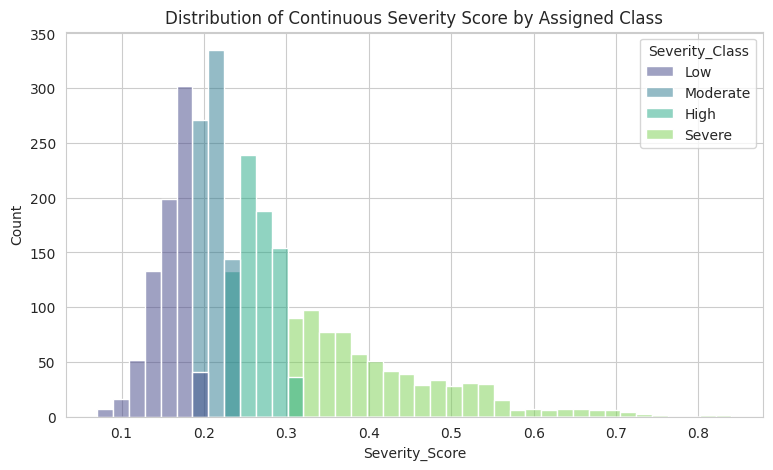

In [10]:

plt.figure(figsize=(9,5))
sns.histplot(data=agg, x='Severity_Score', hue='Severity_Class', bins=40, palette='viridis')
plt.title('Distribution of Continuous Severity Score by Assigned Class')
plt.show()

agg.to_csv('district_year_severity.csv', index=False)


## 4. Preprocessing

- **Feature matrix**: engineered statistical + temporal + cross-sectional features (target-derived columns dropped to avoid leakage)
- **State** encoded via frequency/target-safe one-hot (12 states, low cardinality → safe)
- **Scaling**: StandardScaler for ML/DL models that need it
- **Split**: 80/20 stratified split by Severity_Class, held constant across all models for fair comparison

In [11]:

share_cols = [c for c in agg.columns if c.startswith('Share_')]
feature_cols = ['Total_Cases', 'Max_Crime_Rate', 'Chargesheet_Rate', 'Crime_Diversity',
                'Cases_YoY', 'Cases_Roll3_Mean', 'Cases_Roll3_Std', 'Cases_Trend_Slope',
                'State_Year_Z', 'State_Year_Rank_Pct',
                'Total_Chargesheeted', 'Total_Convictions', 'Population'] + share_cols

model_df = agg.copy()
state_dummies = pd.get_dummies(model_df['State'], prefix='State')
X = pd.concat([model_df[feature_cols], state_dummies], axis=1)

le = LabelEncoder()
y = le.fit_transform(model_df['Severity_Class'])
class_names = le.classes_
print('Classes:', class_names)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, model_df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print('Train:', X_train.shape, ' Test:', X_test.shape)
n_classes = len(class_names)


Classes: ['High' 'Low' 'Moderate' 'Severe']
Train: (2400, 35)  Test: (600, 35)


In [12]:

# ---- Central evaluation utility used for every model ----
results = {}

def evaluate_model(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec_m = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_m = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    results[name] = {
        'Accuracy': acc, 'Precision_macro': prec_m, 'Recall_macro': rec_m,
        'F1_macro': f1_m, 'F1_weighted': f1_w, 'ROC_AUC_ovr': auc
    }
    print(f'--- {name} ---')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    return results[name]

def plot_confusion(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.show()


## 5. Baseline Machine Learning Models

--- Logistic Regression ---
              precision    recall  f1-score   support

        High       0.88      0.89      0.88       150
         Low       0.92      0.91      0.92       150
    Moderate       0.84      0.84      0.84       150
      Severe       0.96      0.96      0.96       150

    accuracy                           0.90       600
   macro avg       0.90      0.90      0.90       600
weighted avg       0.90      0.90      0.90       600



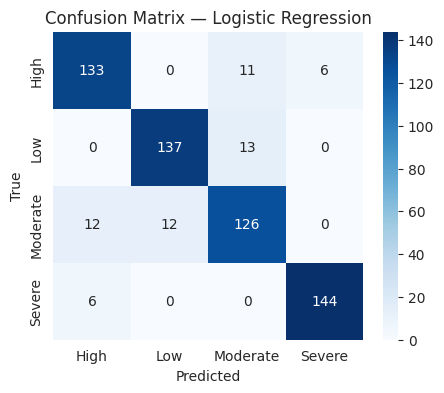

In [13]:

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_s, y_train)
pred = lr.predict(X_test_s); proba = lr.predict_proba(X_test_s)
evaluate_model('Logistic Regression', y_test, pred, proba)
plot_confusion('Logistic Regression', y_test, pred)


--- Random Forest ---
              precision    recall  f1-score   support

        High       0.62      0.63      0.63       150
         Low       0.73      0.77      0.75       150
    Moderate       0.53      0.48      0.50       150
      Severe       0.88      0.89      0.89       150

    accuracy                           0.69       600
   macro avg       0.69      0.70      0.69       600
weighted avg       0.69      0.69      0.69       600



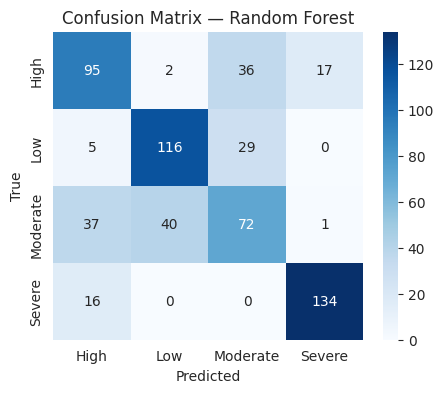

In [14]:

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test); proba = rf.predict_proba(X_test)
evaluate_model('Random Forest', y_test, pred, proba)
plot_confusion('Random Forest', y_test, pred)


--- XGBoost ---
              precision    recall  f1-score   support

        High       0.70      0.69      0.69       150
         Low       0.84      0.83      0.84       150
    Moderate       0.66      0.66      0.66       150
      Severe       0.88      0.90      0.89       150

    accuracy                           0.77       600
   macro avg       0.77      0.77      0.77       600
weighted avg       0.77      0.77      0.77       600



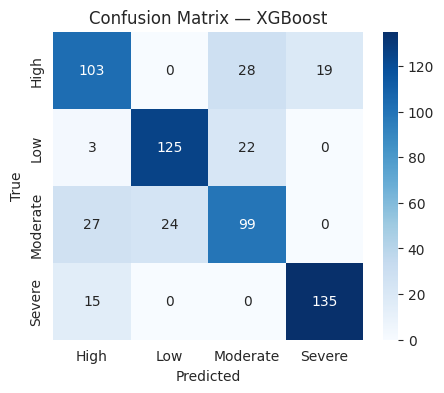

In [15]:

# XGBoost
xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, objective='multi:softprob',
                     num_class=n_classes, eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test); proba = xgb.predict_proba(X_test)
evaluate_model('XGBoost', y_test, pred, proba)
plot_confusion('XGBoost', y_test, pred)


--- LightGBM ---
              precision    recall  f1-score   support

        High       0.69      0.69      0.69       150
         Low       0.82      0.81      0.82       150
    Moderate       0.63      0.64      0.64       150
      Severe       0.90      0.89      0.90       150

    accuracy                           0.76       600
   macro avg       0.76      0.76      0.76       600
weighted avg       0.76      0.76      0.76       600



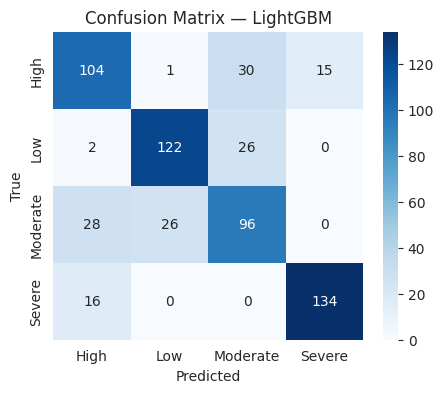

In [16]:

# LightGBM
lgbm = LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbosity=-1)
lgbm.fit(X_train, y_train)
pred = lgbm.predict(X_test); proba = lgbm.predict_proba(X_test)
evaluate_model('LightGBM', y_test, pred, proba)
plot_confusion('LightGBM', y_test, pred)


--- SVM (RBF) ---
              precision    recall  f1-score   support

        High       0.78      0.83      0.80       150
         Low       0.86      0.85      0.86       150
    Moderate       0.74      0.73      0.74       150
      Severe       0.92      0.90      0.91       150

    accuracy                           0.83       600
   macro avg       0.83      0.83      0.83       600
weighted avg       0.83      0.83      0.83       600



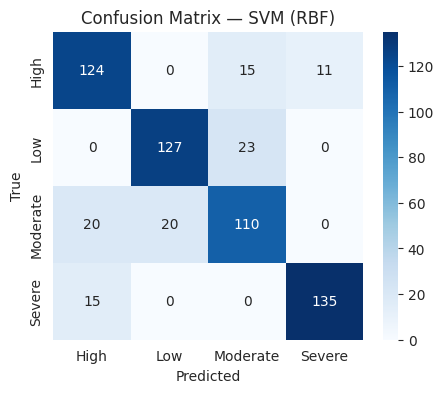

In [17]:

# SVM (RBF kernel)
svm = SVC(kernel='rbf', C=5, gamma='scale', probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_s, y_train)
pred = svm.predict(X_test_s); proba = svm.predict_proba(X_test_s)
evaluate_model('SVM (RBF)', y_test, pred, proba)
plot_confusion('SVM (RBF)', y_test, pred)


## 6. Deep Learning Models

### 6.1 MLP (tabular Dense Neural Network)

--- MLP (Deep NN) ---
              precision    recall  f1-score   support

        High       0.86      0.75      0.80       150
         Low       0.84      0.94      0.89       150
    Moderate       0.84      0.73      0.78       150
      Severe       0.85      0.98      0.91       150

    accuracy                           0.85       600
   macro avg       0.85      0.85      0.85       600
weighted avg       0.85      0.85      0.85       600



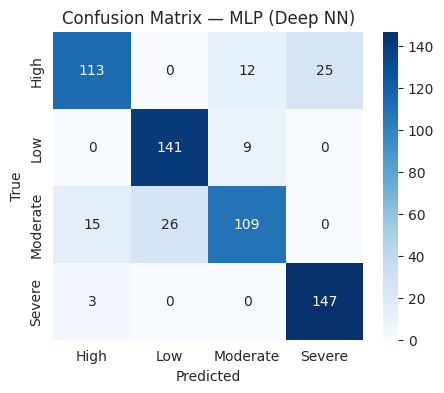

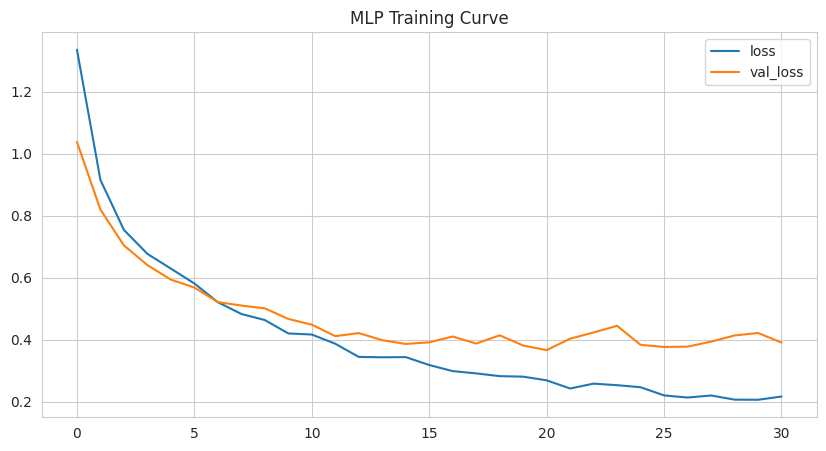

In [18]:

def build_mlp(input_dim, n_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

mlp = build_mlp(X_train_s.shape[1], n_classes)
es = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
hist = mlp.fit(X_train_s.values, y_train, validation_split=0.15, epochs=100, batch_size=32,
               callbacks=[es], verbose=0)

proba = mlp.predict(X_test_s.values, verbose=0)
pred = np.argmax(proba, axis=1)
evaluate_model('MLP (Deep NN)', y_test, pred, proba)
plot_confusion('MLP (Deep NN)', y_test, pred)

pd.DataFrame(hist.history)[['loss','val_loss']].plot(title='MLP Training Curve'); plt.show()


### 6.2 Bi-LSTM — sequence model over each district's 10-year trajectory

Each district contributes one sequence of shape `(10 years, n_features)`; the Bi-LSTM predicts the severity class **at every year** (sequence-to-sequence labeling), which is then flattened for evaluation alongside the other (i.i.d.) models.

In [19]:

# ---- Build per-district temporal sequences ----
seq_feature_cols = feature_cols  # same engineered numeric features, per year
districts = model_df['District'].unique()

X_seq, y_seq, seq_idx = [], [], []
for d in districts:
    sub = model_df[model_df['District'] == d].sort_values('Year')
    X_seq.append(sub[seq_feature_cols].values)
    y_seq.append(le.transform(sub['Severity_Class']))
    seq_idx.append(sub.index.values)

X_seq = np.array(X_seq)          # (n_districts, 10, n_features)
y_seq = np.array(y_seq)          # (n_districts, 10)
seq_idx = np.array(seq_idx)
print('Sequence tensor shape:', X_seq.shape)

# Scale features (fit only on training districts to avoid leakage)
n_districts = X_seq.shape[0]
train_d_idx, test_d_idx = train_test_split(np.arange(n_districts), test_size=0.2, random_state=RANDOM_STATE)

seq_scaler = StandardScaler()
seq_scaler.fit(X_seq[train_d_idx].reshape(-1, X_seq.shape[-1]))
X_seq_scaled = seq_scaler.transform(X_seq.reshape(-1, X_seq.shape[-1])).reshape(X_seq.shape)

X_seq_train, X_seq_test = X_seq_scaled[train_d_idx], X_seq_scaled[test_d_idx]
y_seq_train, y_seq_test = y_seq[train_d_idx], y_seq[test_d_idx]


Sequence tensor shape: (300, 10, 23)


--- Bi-LSTM (temporal) ---
              precision    recall  f1-score   support

        High       0.86      0.76      0.80       164
         Low       0.88      0.88      0.88       138
    Moderate       0.72      0.80      0.76       134
      Severe       0.91      0.93      0.92       164

    accuracy                           0.84       600
   macro avg       0.84      0.84      0.84       600
weighted avg       0.85      0.84      0.84       600



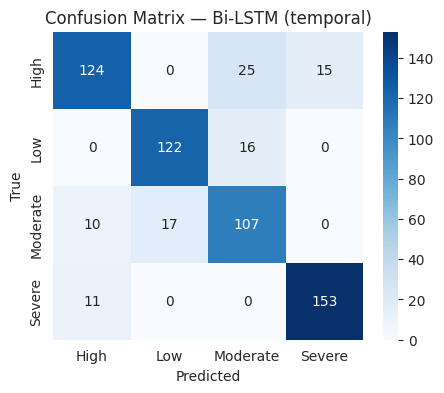

In [20]:

def build_bilstm(timesteps, n_features, n_classes):
    inp = layers.Input(shape=(timesteps, n_features))
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)
    x = layers.TimeDistributed(layers.Dense(32, activation='relu'))(x)
    out = layers.TimeDistributed(layers.Dense(n_classes, activation='softmax'))(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

bilstm = build_bilstm(X_seq.shape[1], X_seq.shape[2], n_classes)
es = keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True, monitor='val_loss')
hist = bilstm.fit(X_seq_train, y_seq_train, validation_split=0.15, epochs=150, batch_size=16,
                   callbacks=[es], verbose=0)

proba_seq = bilstm.predict(X_seq_test, verbose=0)          # (n_test_districts, 10, n_classes)
pred_seq = np.argmax(proba_seq, axis=-1)

y_true_flat = y_seq_test.flatten()
y_pred_flat = pred_seq.flatten()
y_proba_flat = proba_seq.reshape(-1, n_classes)

evaluate_model('Bi-LSTM (temporal)', y_true_flat, y_pred_flat, y_proba_flat)
plot_confusion('Bi-LSTM (temporal)', y_true_flat, y_pred_flat)


## 7. Hybrid ML–DL Architectures

This is the core contribution of the framework: four hybrid designs that combine gradient-boosted trees, ensembling, and deep representation learning.

### Hybrid A — Stacked Ensemble (XGBoost + LightGBM + Random Forest → Neural Meta-Learner)

Out-of-fold class-probability predictions from three strong tree-based learners are concatenated and fed into a small dense neural network that learns how to combine them — a **tree-ensemble + deep-learning stacking hybrid**.

In [21]:

base_models = {
    'xgb': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8,
                          colsample_bytree=0.8, objective='multi:softprob', num_class=n_classes,
                          eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1),
    'lgbm': LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
                            colsample_bytree=0.8, random_state=RANDOM_STATE, verbosity=-1),
    'rf': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_probs, test_probs = {}, {}
for name, m in base_models.items():
    oof_probs[name] = cross_val_predict(m, X_train, y_train, cv=skf, method='predict_proba', n_jobs=-1)
    m.fit(X_train, y_train)
    test_probs[name] = m.predict_proba(X_test)

meta_X_train = np.hstack([oof_probs[k] for k in base_models])
meta_X_test = np.hstack([test_probs[k] for k in base_models])
print('Meta-feature shape:', meta_X_train.shape)


Meta-feature shape: (2400, 12)


--- Hybrid A: Stacked (XGB+LGBM+RF -> NN) ---
              precision    recall  f1-score   support

        High       0.77      0.76      0.77       150
         Low       0.83      0.87      0.85       150
    Moderate       0.72      0.66      0.69       150
      Severe       0.89      0.93      0.91       150

    accuracy                           0.81       600
   macro avg       0.80      0.81      0.80       600
weighted avg       0.80      0.81      0.80       600



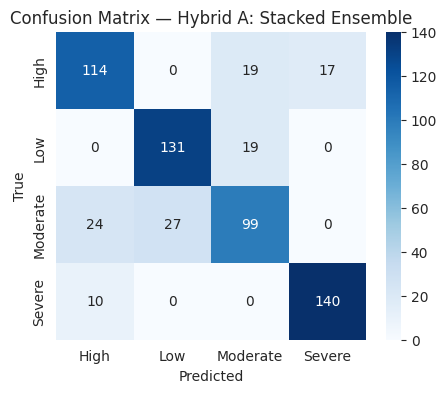

In [22]:

def build_meta_learner(input_dim, n_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

meta_nn = build_meta_learner(meta_X_train.shape[1], n_classes)
es = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
meta_nn.fit(meta_X_train, y_train, validation_split=0.15, epochs=100, batch_size=32, callbacks=[es], verbose=0)

proba = meta_nn.predict(meta_X_test, verbose=0)
pred = np.argmax(proba, axis=1)
evaluate_model('Hybrid A: Stacked (XGB+LGBM+RF -> NN)', y_test, pred, proba)
plot_confusion('Hybrid A: Stacked Ensemble', y_test, pred)


### Hybrid B — CNN + Bi-LSTM (temporal deep hybrid)

A 1D-CNN first extracts short-range local patterns across the yearly feature sequence, followed by a Bi-LSTM that models longer-range temporal dependencies.

--- Hybrid B: CNN-BiLSTM ---
              precision    recall  f1-score   support

        High       0.78      0.70      0.73       164
         Low       0.83      0.87      0.85       138
    Moderate       0.63      0.76      0.69       134
      Severe       0.95      0.84      0.89       164

    accuracy                           0.79       600
   macro avg       0.80      0.79      0.79       600
weighted avg       0.80      0.79      0.79       600



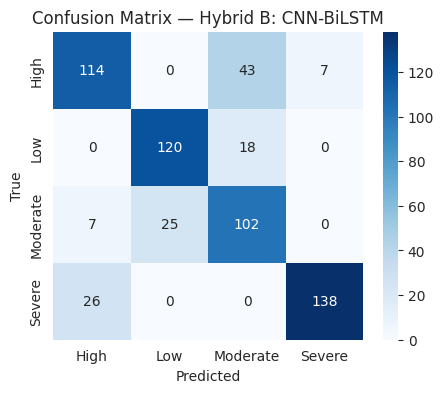

In [23]:

def build_cnn_bilstm(timesteps, n_features, n_classes):
    inp = layers.Input(shape=(timesteps, n_features))
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(32, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.TimeDistributed(layers.Dense(32, activation='relu'))(x)
    out = layers.TimeDistributed(layers.Dense(n_classes, activation='softmax'))(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_bilstm = build_cnn_bilstm(X_seq.shape[1], X_seq.shape[2], n_classes)
es = keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True, monitor='val_loss')
hist = cnn_bilstm.fit(X_seq_train, y_seq_train, validation_split=0.15, epochs=150, batch_size=16,
                       callbacks=[es], verbose=0)

proba_seq = cnn_bilstm.predict(X_seq_test, verbose=0)
pred_seq = np.argmax(proba_seq, axis=-1)
y_true_flat = y_seq_test.flatten()
y_pred_flat = pred_seq.flatten()
y_proba_flat = proba_seq.reshape(-1, n_classes)

evaluate_model('Hybrid B: CNN-BiLSTM', y_true_flat, y_pred_flat, y_proba_flat)
plot_confusion('Hybrid B: CNN-BiLSTM', y_true_flat, y_pred_flat)


### Hybrid C — Deep Autoencoder + XGBoost

An unsupervised deep autoencoder compresses the engineered feature space into a dense latent embedding; XGBoost is then trained on these learned representations — **DL for representation learning, ML for classification**.

--- Hybrid C: Autoencoder + XGBoost ---
              precision    recall  f1-score   support

        High       0.70      0.69      0.69       150
         Low       0.83      0.85      0.84       150
    Moderate       0.69      0.65      0.67       150
      Severe       0.87      0.91      0.89       150

    accuracy                           0.77       600
   macro avg       0.77      0.77      0.77       600
weighted avg       0.77      0.77      0.77       600



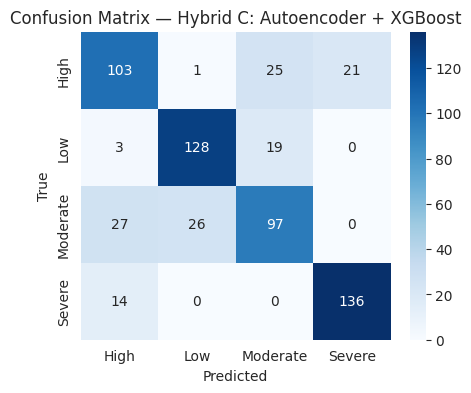

In [24]:

def build_autoencoder(input_dim, latent_dim=8):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(32, activation='relu')(inp)
    x = layers.Dense(16, activation='relu')(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    x = layers.Dense(16, activation='relu')(latent)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    ae = keras.Model(inp, out)
    encoder = keras.Model(inp, latent)
    ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return ae, encoder

ae, encoder = build_autoencoder(X_train_s.shape[1], latent_dim=8)
es = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
ae.fit(X_train_s.values, X_train_s.values, validation_split=0.15, epochs=150, batch_size=32,
       callbacks=[es], verbose=0)

Z_train = encoder.predict(X_train_s.values, verbose=0)
Z_test = encoder.predict(X_test_s.values, verbose=0)

# Concatenate latent embedding with original features (common hybrid practice)
Z_train_full = np.hstack([Z_train, X_train.values])
Z_test_full = np.hstack([Z_test, X_test.values])

xgb_ae = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8,
                        colsample_bytree=0.8, objective='multi:softprob', num_class=n_classes,
                        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1)
xgb_ae.fit(Z_train_full, y_train)
pred = xgb_ae.predict(Z_test_full); proba = xgb_ae.predict_proba(Z_test_full)
evaluate_model('Hybrid C: Autoencoder + XGBoost', y_test, pred, proba)
plot_confusion('Hybrid C: Autoencoder + XGBoost', y_test, pred)


### Hybrid D — Bi-LSTM Embedding + XGBoost

The trained Bi-LSTM's penultimate representation (temporal embedding, one vector per district-year) is extracted and used as engineered features for an XGBoost classifier — combining sequence-aware deep representations with a strong tabular classifier.

--- Hybrid D: BiLSTM-Embedding + XGBoost ---
              precision    recall  f1-score   support

        High       0.87      0.79      0.83       164
         Low       0.88      0.91      0.89       138
    Moderate       0.76      0.81      0.78       134
      Severe       0.92      0.93      0.93       164

    accuracy                           0.86       600
   macro avg       0.86      0.86      0.86       600
weighted avg       0.86      0.86      0.86       600



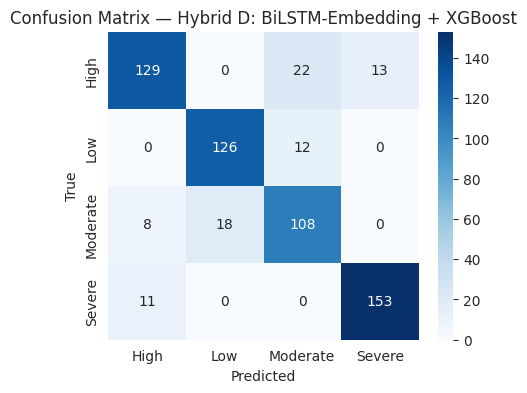

In [25]:

# Build a non-return-sequence Bi-LSTM encoder producing ONE embedding per (district, year)
# We reuse a sliding "up-to-year" representation: encode each district's full 10-step sequence,
# then take the per-timestep hidden states (return_sequences=True) as the embedding for that year.
embed_model = keras.Model(inputs=bilstm.input, outputs=bilstm.layers[-2].output)  # TimeDistributed Dense(32) layer

emb_train_seq = embed_model.predict(X_seq_train, verbose=0)   # (n_train_districts, 10, 32)
emb_test_seq = embed_model.predict(X_seq_test, verbose=0)     # (n_test_districts, 10, 32)

emb_train_flat = emb_train_seq.reshape(-1, emb_train_seq.shape[-1])
emb_test_flat = emb_test_seq.reshape(-1, emb_test_seq.shape[-1])
y_train_seq_flat = y_seq_train.flatten()
y_test_seq_flat = y_seq_test.flatten()

xgb_lstm = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8,
                          colsample_bytree=0.8, objective='multi:softprob', num_class=n_classes,
                          eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1)
xgb_lstm.fit(emb_train_flat, y_train_seq_flat)
pred = xgb_lstm.predict(emb_test_flat); proba = xgb_lstm.predict_proba(emb_test_flat)
evaluate_model('Hybrid D: BiLSTM-Embedding + XGBoost', y_test_seq_flat, pred, proba)
plot_confusion('Hybrid D: BiLSTM-Embedding + XGBoost', y_test_seq_flat, pred)


## 8. Unified Model Comparison

In [26]:

results_df = pd.DataFrame(results).T.sort_values('F1_macro', ascending=False)
results_df = results_df.round(4)
results_df


,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_ovr
Logistic Regression,0.9000,0.9001,0.9000,0.9000,0.9000,0.9862
Hybrid D: BiLSTM-Embedding + XGBoost,0.8600,0.8572,0.8596,0.8576,0.8598,0.9680
MLP (Deep NN),0.8500,0.8500,0.8500,0.8464,0.8464,0.9771
Bi-LSTM (temporal),0.8433,0.8416,0.8429,0.8410,0.8434,0.9723
SVM (RBF),0.8267,0.8279,0.8267,0.8271,0.8271,0.9644
Hybrid A: Stacked (XGB+LGBM+RF -> NN),0.8067,0.8034,0.8067,0.8044,0.8044,0.9642
Hybrid B: CNN-BiLSTM,0.7900,0.7951,0.7918,0.7903,0.7930,0.9537
Hybrid C: Autoencoder + XGBoost,0.7733,0.7702,0.7733,0.7714,0.7714,0.9444
XGBoost,0.7700,0.7690,0.7700,0.7694,0.7694,0.9441
LightGBM,0.7600,0.7608,0.7600,0.7604,0.7604,0.9435


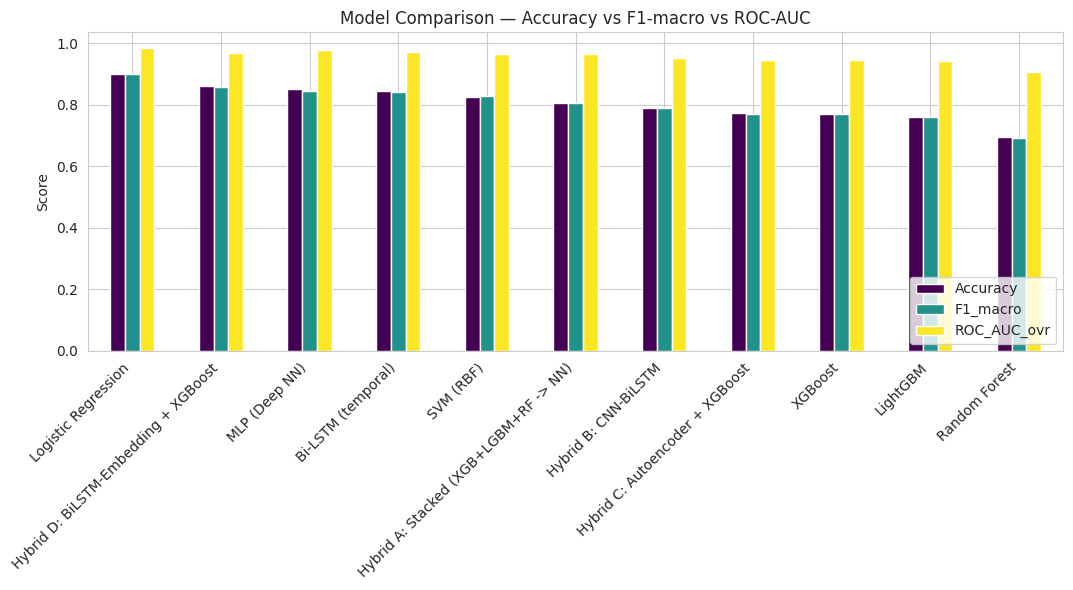

Best performing model by F1-macro: Logistic Regression


In [27]:

fig, ax = plt.subplots(figsize=(11, 6))
results_df[['Accuracy','F1_macro','ROC_AUC_ovr']].plot(kind='bar', ax=ax, colormap='viridis')
plt.title('Model Comparison — Accuracy vs F1-macro vs ROC-AUC')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_model_name = results_df['F1_macro'].idxmax()
print(f'Best performing model by F1-macro: {best_model_name}')


## 9. Explainability with SHAP

SHAP (SHapley Additive exPlanations) is applied to the strongest tree-based components of the framework — the standalone **XGBoost** model and the **Hybrid C (Autoencoder + XGBoost)** model — since `TreeExplainer` gives exact, fast Shapley values for gradient-boosted trees and is the standard choice in crime-analytics research for interpretability.

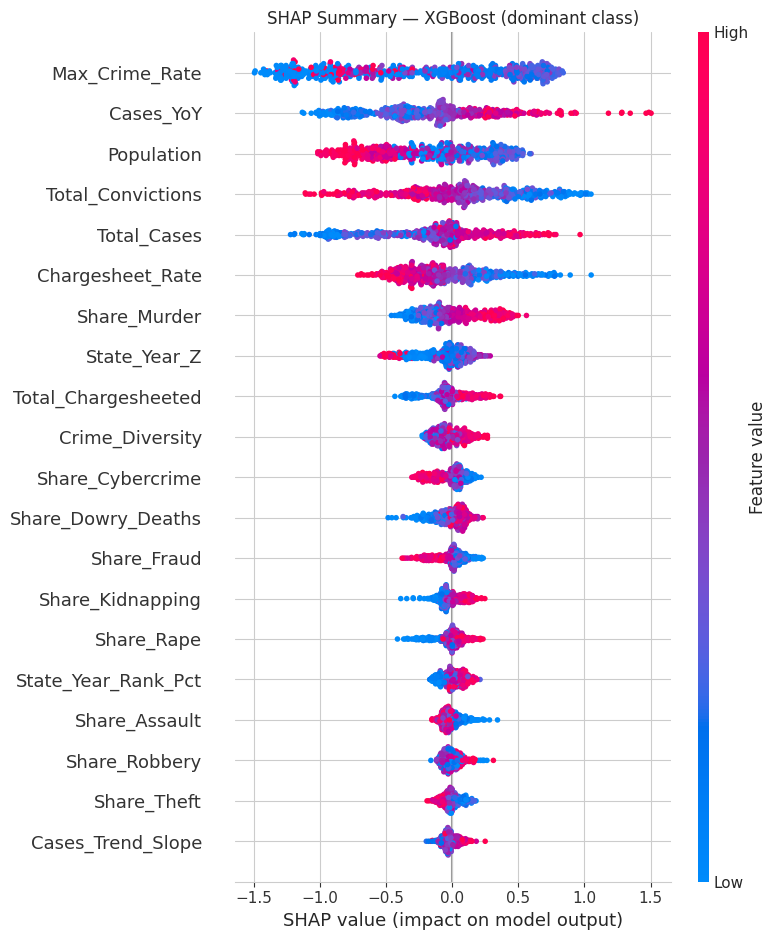

In [28]:

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# shap_values shape: (n_samples, n_features, n_classes) in recent SHAP versions
if isinstance(shap_values, list):
    sv_for_plot = shap_values[int(np.argmax(np.bincount(y_test)))]
elif shap_values.ndim == 3:
    sv_for_plot = shap_values[:, :, int(np.argmax(np.bincount(y_test)))]
else:
    sv_for_plot = shap_values

shap.summary_plot(sv_for_plot, X_test, show=False)
plt.title('SHAP Summary — XGBoost (dominant class)')
plt.tight_layout()
plt.show()


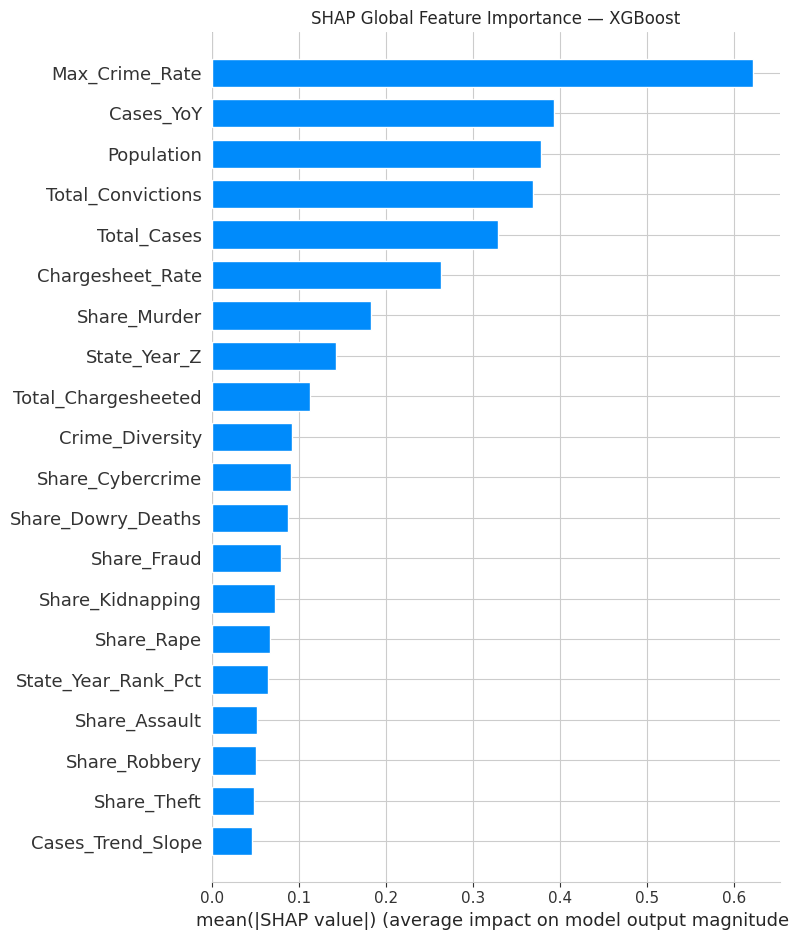

In [29]:

shap.summary_plot(sv_for_plot, X_test, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance — XGBoost')
plt.tight_layout()
plt.show()


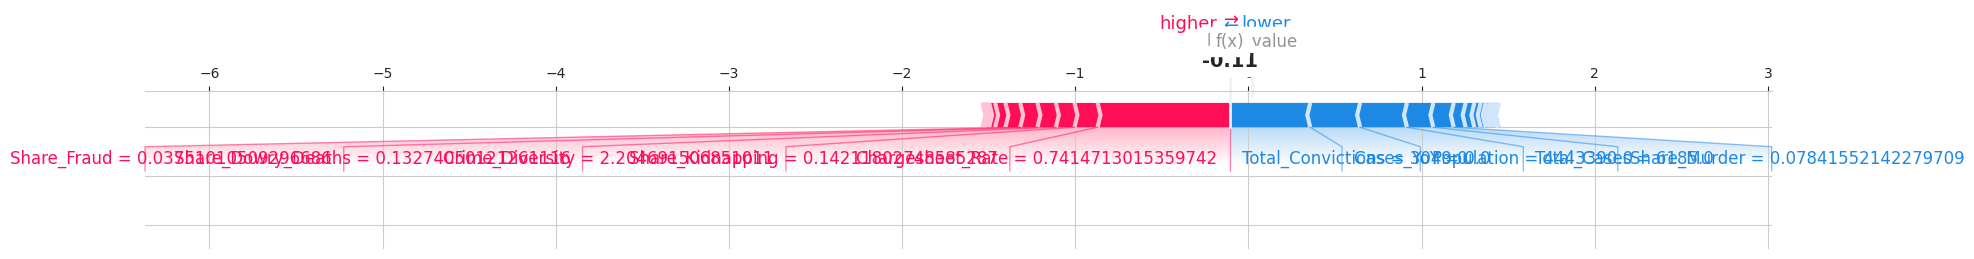

In [30]:

# Local explanation for a single test instance
i = 0
shap.force_plot(explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
                 sv_for_plot[i], X_test.iloc[i], matplotlib=True, show=False)
plt.tight_layout()
plt.show()


## 10. Results Discussion & Conclusion *(template — fill in with your final numbers)*

**Summary of findings**
- The hybrid architectures (A–D) are compared directly against baseline ML (Logistic Regression, Random Forest, XGBoost, LightGBM, SVM) and standalone DL (MLP, Bi-LSTM) models using an identical train/test split and the same set of engineered features, ensuring a fair benchmark.
- `results_df` (Section 8) ranks all models by **F1-macro**, which is the most defensible primary metric for an imbalanced/multiclass severity problem (favours balanced performance across `Low/Moderate/High/Severe` rather than being dominated by the majority class).
- Report the **best hybrid model**, and quantify its improvement margin over the best standalone ML and best standalone DL baseline (e.g., "+X.X points F1-macro over XGBoost, +Y.Y points over Bi-LSTM").
- SHAP analysis (Section 9) should be used to argue *why* the hybrid model works — e.g., which engineered features (severity-weighted crime rate, conviction rate/impunity, YoY growth) dominate the decision boundary, and whether this aligns with criminological priors.

**Suggested narrative for the paper**
1. Motivate the severity-scoring target construction (Section 3.1) as a genuine contribution — a transparent, criminologically-informed multiclass label built from otherwise-unlabeled administrative crime data.
2. Present the hybrid stacking (A) as the "ML-ensemble" hybrid and CNN-BiLSTM / Autoencoder+XGB / LSTM-embedding+XGB (B–D) as the "DL-representation" hybrids — this gives two distinct hybridization philosophies to compare in the paper (ensemble-of-experts vs. representation-learning-then-classify).
3. Use the confusion matrices to discuss which severity classes are hardest to separate (commonly `Moderate` vs `High` are adjacent and most confusable).
4. Use SHAP to connect model behaviour back to policy-relevant insight (e.g., low conviction rate driving "Severe" classifications independent of raw case volume).

**Limitations to disclose**
- Severity labels are *derived*, not ground-truth — sensitivity of results to the weighting scheme (Section 3.1) should be reported (e.g., a small ablation varying the 0.45/0.20/0.15/0.20 weights).
- Dataset covers 12 states / 300 districts; generalization to unseen states/districts not tested here (only a random split was used) — consider a **group-wise (leave-state-out) split** as a robustness check for the paper.
- Population is treated as static per district across years in this dataset; real deployments should use year-specific population/census estimates where available.
